# STCS Tutorial for Stereo-seq

This tutorial is used to run the complete STCS pipeline based on the merged `STCS_main.py` module. 

**Please run the conversion steps, Convert_GEM_h5ad.ipynb, for Stereo-seq GEM file before running this notebook.**

The pipeline includes:

1. **Data Preparation**: Loading and cropping spatial data

2. **Cell Segmentation**: Segmentation pipeline for nucleus detection

3. **Pseudobulk Creation**: Aggregating spots into cell-level data

4. **PCA Assignment**: Gene space assignment with reference data

5. **Cell Type Annotation**: CellTypist-based annotation

6. **Visualization**: Spatial plotting of results

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq


# Import the STCS module
sys.path.append("STCS")
from STCS_main import STCS 

# For visualization
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import plot
from matplotlib.colors import ListedColormap
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

# Set up paths

In [ ]:
# Define data type, here we choose Stereo-seq
PLATFORM ="Stereo-seq" 

# TODO: replace the path with the Directory that contain your h5ad
FOLDER_PATH = ""

# TODO: replace the path with your h5ad file converted from GEM
DATA_PATH = "./C04042E3.h5ad"

# TODO: replace the path with full resolution H&E image paired with Stereo-seq data. Make sure they are aligned
FULL_RES_IMAGE_PATH = "./C04042E3_HE_regist.tif"

# TODO: Replace with a paired SCrna-seq h5ad file if you have one, else use None
SC_REF_PATH = "/lab01/lc1418/Downsampled_scRNA_mousebrain/whole_brain_reference.h5ad"

# TODO: Replace with the path of CellTypist model for celltype annotation. You can replace this with your trained model for your specific tissue or manually  annotate the aggregated cell. 
MODEL_PATH = '/home/lc1418/ST/Ourmethod/results/model/Mouse_Whole_Brain.pkl'

In [13]:
# TODO: Replace path with the output Directory
RESULTS_PATH = "./result"

# Create results directory
os.makedirs(RESULTS_PATH, exist_ok=True)

# 1. Data Preparation and Loading

Start by loading the full spatial transcriptomics dataset and cropping a region of interest for faster processing.

## Load full data

In [14]:
# Load the full dataset
full_data = STCS(
    Folder_path=FOLDER_PATH,
    counts_data=DATA_PATH,
    full_res_image_path=FULL_RES_IMAGE_PATH,
    sc_ref=SC_REF_PATH,
    model_path=MODEL_PATH,
    Platform = PLATFORM
)

[Log]: Loaded Stereo-seq data with 104429812 spots
[Log]: Found spatial info
[Log]: STCS loaded: 104429812 spots, 27441 genes


In [15]:
x1, x2, y1, y2 = full_data.get_sequencing_data_region()
print(f"Data region bounds: x=({x1}, {x2}), y=({y1}, {y2})")

Data region bounds: x=(3606, 20855), y=(2894, 21245)


## Crop

In [16]:
# Crop a region of interest for faster processing
# Adjust these coordinates based on your data
crop_x1 = 11000
crop_y1 = 6000
crop_size = 2000  # 5000x5000 pixel region

crop_x2 = crop_x1 + crop_size
crop_y2 = crop_y1 + crop_size

print(f"Cropping region: ({crop_x1}, {crop_y1}) to ({crop_x2}, {crop_y2})")

Cropping region: (11000, 6000) to (13000, 8000)


In [17]:
# Apply crop
crop_data = full_data.crop(
    x1=crop_x1,
    x2=crop_x2,
    y1=crop_y1,
    y2=crop_y2,
)


[Log]: Cropped region aligned to 0, 0, 1999, 1999
[Log]: Cropped from 104429812 to 1881316 spots


In [18]:
#For full tissue: 
# crop_data = full_data

[Log]: Returning cropped image from memory.


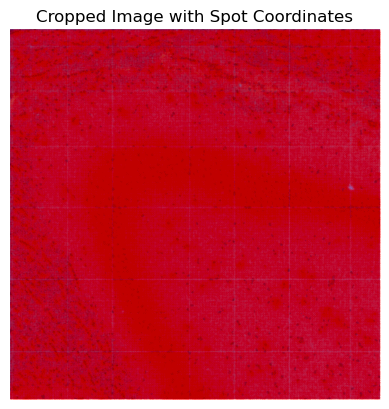

In [19]:


if crop_data is None:
    raise RuntimeError("Cropping failed!")

#  Load cropped image
crop_img = crop_data.load_img()
if crop_img is None:
    raise RuntimeError("Cropped image could not be loaded!")

#  Visualize cropped image and spatial coordinates
plt.imshow(crop_img)
spatial = crop_data.adata.obsm["spatial"]
plt.scatter(spatial[:, 0], spatial[:, 1], s=0.05, c="red", alpha = 0.05)
plt.title("Cropped Image with Spot Coordinates")
plt.axis("off")
plt.show()

## Save the cropped data

In [20]:
crop_data.save(RESULTS_PATH)

[Log]: STCS data saved to ./result


# 2. Cell Segmentation

Next, we perform cell segmentation

In [21]:
# load the cropped data so that we could skip the cropping step in future runs
crop_data = STCS.from_saved(RESULTS_PATH)

[Log]: Loaded cropped image from ./result/cropped_image.tif
[Log]: STCS loaded raw data from ./result: 1881316 spots, 27441 genes


## Segmentation

In [22]:
crop_data_segmented = crop_data.run_stardist_pipeline(
    RESULTS_PATH,
    prob_thresh=0.1)

[Log]: Starting stardist pipeline
[Debug]: has cropped_img? True
[Debug]: cropped_img is None? False
[Debug]: cropped_img shape: (2000, 2000, 3)
[Log]: Using cropped image for stardist pipeline.
Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


 75%|███████▌  | 12/16 [00:02<00:00,  6.27it/s]

100%|██████████| 16/16 [00:03<00:00,  5.27it/s]


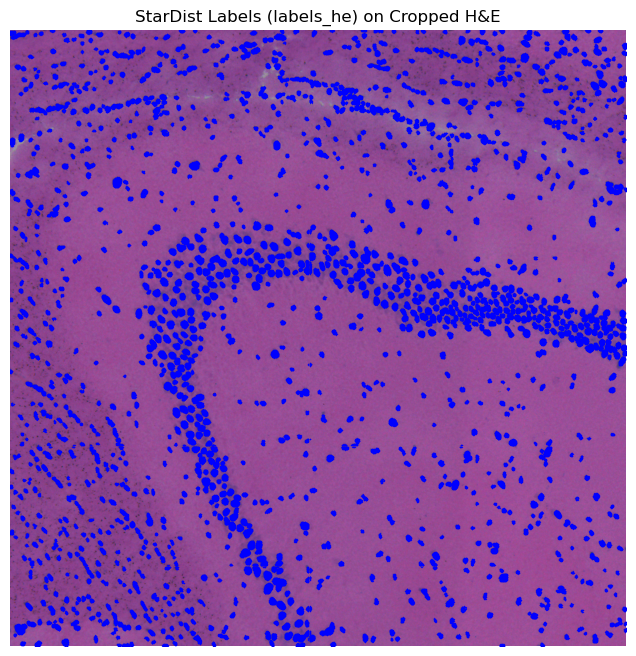

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Grab the cropped image
img = crop_data_segmented.cropped_img

# 2. Pull out the spatial coords and labels from your AnnData
coords = crop_data_segmented.adata.obsm['spatial']    # shape (n_spots, 2): [row, col]
labels = crop_data_segmented.adata.obs['labels_he'].astype(int).values

# 3. (Optional) mask out background spots
mask = labels != 0
coords = coords[mask]
labels = labels[mask]

# 4. Plot
plt.figure(figsize=(8,8))
plt.imshow(img)  # true‐color H&E

# scatter: x=col, y=row; color by label ID
plt.scatter(
    coords[:,0],   # x-axis (column)
    coords[:,1],   # y-axis (row)
    c="blue",      # integer labels
    s=1,           # adjust point size
    linewidth=0,
    alpha=0.8
)

plt.axis('off')
plt.title('StarDist Labels (labels_he) on Cropped H&E')
plt.show()


In [24]:
crop_data_segmented.save(RESULTS_PATH)

[Log]: STCS data saved to ./result


# 3. Pseudobulk Generation

We create pseudobulk data by aggregating gene expression from spots assigned to the same cell.

In [25]:
# load the cropped data so that we could skip the cropping step in future runs
crop_data_segmented = STCS.from_saved(RESULTS_PATH)

[Log]: Loaded cropped image from ./result/cropped_image.tif
[Log]: STCS loaded raw data from ./result: 1881316 spots, 27441 genes


In [26]:
crop_data_with_pseudobulk = crop_data_segmented.create_pseudobulk_from_stardist(
    output_path=RESULTS_PATH,
    mode='mean',
)

[Log]: Starting pseudobulk creation from stardist results
[Log]: Loading stardist barcode data
[Log]: Processing 1881316 common barcodes


Assigning labels_he: 100%|██████████| 19/19 [00:01<00:00, 11.63chunk/s]


[Log]: Assigned labels to 1881316 cells
[Log]: Creating pseudobulk based on labels_he
[Log]: Found 1885 unique groups
[Log]: Starting vectorized mean aggregation...
[Log]: Creating final pseudobulk object...
[Log]: Successfully created pseudobulk with 1885 cells and 27441 genes
[Log]: Pseudobulk creation completed
[Log]: Results saved to ./result/pseudobulk


In [27]:
crop_data_with_pseudobulk.save(RESULTS_PATH)

[Log]: STCS data saved to ./result


# 4. PCA-based Assignment

We perform gene space assignment using PCA to match barcodes to cells based on transcriptomic similarity.

In [28]:
# Use the optimal search radius from parameter tuning
optimal_search_radius = 30  # Use result from parameter tuning or set manually

crop_data_assigned = crop_data_with_pseudobulk.run_assignment(
    output_path=RESULTS_PATH,
    search_radius=optimal_search_radius,
    use_sc_ref=True,  # Use single-cell reference if available
    normalize_distances=True,  # Whether to normalize transcriptomic distances
    feature_name=True # Whether sc reference uses feature names instead of gene symbols
)

[Log]: Starting assignment pipeline based on candidate search + PCA processing + gene space assignment 
[Log]: Creating barcode to candidate cells mapping
[Log]: Creating barcode candidates mapping with precomputed circle offsets
[Log]: Processed 0/1881316 barcodes
[Log]: Processed 500000/1881316 barcodes
[Log]: Processed 1000000/1881316 barcodes
[Log]: Processed 1500000/1881316 barcodes
[Log]: Created candidates mapping for 1881316 barcodes
[Log]: Candidates mapping saved to: ./result/integrated_assignment/barcode_candidates.json
[Log]: Loading pseudobulk data
[Log]: Processing with single-cell reference
[Log]: Loading scRNA-seq reference data
[Log]: Processing pseudobulk data
[Debug] pseudobulk shape before filtering: (1885, 27441)
[Log]: Found 4926 common genes
[Log]: Processing spatial adata
[Log]: Projecting 1881316 samples to PCA space
[Log]: Processing batch 1/38
[Log]: Processing batch 6/38
[Log]: Processing batch 11/38
[Log]: Processing batch 16/38
[Log]: Processing batch 21/3

Final assignment: 100%|██████████| 1881316/1881316 [00:02<00:00, 708847.52it/s]


[Log]: Assigned 1487946 barcodes
[Log]: Saving integrated assignment results
[Log]: Assignment is done
[Log]: Results saved to ./result/integrated_assignment


In [29]:
crop_data_assigned.adata.obs

,array_row,array_col,labels_he,assigned_cell_id
s_002um_11013_06584-1,6584,11013,0,None
s_002um_11026_06868-1,6868,11026,0,340
s_002um_11052_07223-1,7223,11052,0,1681
s_002um_11058_06140-1,6140,11058,0,732
s_002um_11058_07499-1,7499,11058,0,1261
...,...,...,...,...
s_002um_12727_07127-1,7127,12727,0,313
s_002um_12270_07913-1,7913,12270,1016,1016
s_002um_11223_06655-1,6655,11223,0,None
s_002um_12684_06250-1,6250,12684,0,480


In [30]:
crop_data_assigned.save(RESULTS_PATH)

... storing 'assigned_cell_id' as categorical


[Log]: STCS data saved to ./result


# 5. Cell Type Annotation with CellTypist

We annotate the assigned cells using CellTypist to predict cell types based on gene expression. Here, because we added a converting code to convert gene name from ensembl to 

In [31]:
crop_data_assigned = STCS.from_saved(RESULTS_PATH)

[Log]: Loaded cropped image from ./result/cropped_image.tif
[Log]: STCS loaded raw data from ./result: 1881316 spots, 27441 genes


In [32]:
import mygene

adata = crop_data_assigned.adata
ens_ids = adata.var_names.tolist()

# 1. Batch‐query with returnall=True so we can inspect duplicates/missing if needed
mg = mygene.MyGeneInfo()
query_res = mg.querymany(
    ens_ids,
    scopes='ensembl.gene',
    fields='symbol',
    species='mouse',
    as_dataframe=True,
    returnall=True
)

# The actual results DataFrame:
df = query_res['out']  # this has one row per hit, including duplicates

# 2. Drop duplicate queries, keeping the first hit for each Ensembl ID
df_unique = df[~df.index.duplicated(keep='first')]

# 3. Build mapping dict: Ensembl → symbol
mapping = df_unique['symbol'].dropna().to_dict()

# 4. Report how many mapped vs how many missing
n_mapped   = len(mapping)
n_missing  = len(ens_ids) - n_mapped
print(f"{n_mapped} genes mapped to symbols, {n_missing} will fall back to Ensembl IDs.")

# 5. Store original IDs and the new symbol in adata.var
adata.var['ensembl_id']  = ens_ids
adata.var['gene_symbol'] = [mapping.get(e, e) for e in ens_ids]

# 6. Replace var_names with gene_symbol
adata.var_names = adata.var['gene_symbol']

# 7. (Optional) Drop any truly duplicate symbols
adata = adata[:, ~adata.var_names.duplicated()].copy()

# Update back into your STCS object and rerun annotation:
crop_data_assigned.adata = adata

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
querying 1-1000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 1001-2000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 2001-3000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 3001-4000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 4001-5000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 5001-6000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 6001-7000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 7001-8000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 8001-9000 ...
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
querying 9001-10000 ...
HTTP Request: POS

26715 genes mapped to symbols, 726 will fall back to Ensembl IDs.


In [33]:
crop_data_assigned.adata.var

,ensembl_id,gene_symbol
gene_symbol,,
Gnai3,ENSMUSG00000000001,Gnai3
Pbsn,ENSMUSG00000000003,Pbsn
Cdc45,ENSMUSG00000000028,Cdc45
H19,ENSMUSG00000000031,H19
Scml2,ENSMUSG00000000037,Scml2
...,...,...
4930549P19Rik,ENSMUSG00000116984,4930549P19Rik
Gm49625,ENSMUSG00000116987,Gm49625
Gm49673,ENSMUSG00000116988,Gm49673


In [34]:
crop_data_annotated = crop_data_assigned.run_celltypist_annotation(
    output_path=RESULTS_PATH,
    train_celltypist_model=False
)

[Log]: Starting CellTypist annotation pipeline
[Log]: Creating pseudobulk for CellTypist
[Log]: Starting pseudobulk creation from assignment results
[Log]: Creating pseudobulk based on assigned_cell_id
[Log]: Found 1885 unique groups
[Log]: Starting vectorized sum aggregation...
[Log]: Creating final pseudobulk object...
[Log]: Successfully created pseudobulk with 1885 cells and 27416 genes
[Log]: Pseudobulk creation completed
[Log]: Results saved to ./result/pseudobulk
[Log]: Removed 'unassigned' cell from pseudobulk data
[Log]: Running CellTypist annotation
[Log]: Using model: /home/lc1418/ST/Ourmethod/results/model/Mouse_Whole_Brain.pkl


🔬 Input data has 1884 cells and 27416 genes
🔗 Matching reference genes in the model
🧬 5254 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


[Log]: Saving annotated results
[Log]: Merging back column: predicted_labels
[Log]: Merging back column: over_clustering
[Log]: Merging back column: majority_voting
[Log]: Merging back column: conf_score


... storing 'celltypist_predicted_labels' as categorical
... storing 'celltypist_over_clustering' as categorical
... storing 'celltypist_majority_voting' as categorical


[Log]: CellTypist annotation completed
[Log]: Results saved to ./result/celltypist_annotation


# 6. Visualization

We create spatial visualizations of the annotated cell types.

In [35]:
annotated_adata = crop_data_annotated.adata.copy()

In [36]:
import scanpy as sc


print(annotated_adata)


AnnData object with n_obs × n_vars = 1881316 × 27416
    obs: 'array_row', 'array_col', 'labels_he', 'assigned_cell_id', 'celltypist_predicted_labels', 'celltypist_over_clustering', 'celltypist_majority_voting', 'celltypist_conf_score'
    var: 'ensembl_id', 'gene_symbol'
    uns: 'spatial'
    obsm: 'spatial'


In [37]:
annotated_adata.obs

,array_row,array_col,labels_he,assigned_cell_id,celltypist_predicted_labels,celltypist_over_clustering,celltypist_majority_voting,celltypist_conf_score
s_002um_11013_06584-1,6584,11013,0,NaN,nan,nan,nan,NaN
s_002um_11026_06868-1,6868,11026,0,340,327 Oligo NN,7,327 Oligo NN,0.320412
s_002um_11052_07223-1,7223,11052,0,1681,321 Astroependymal NN,72,319 Astro-TE NN,0.071192
s_002um_11058_06140-1,6140,11058,0,732,327 Oligo NN,35,327 Oligo NN,0.206389
s_002um_11058_07499-1,7499,11058,0,1261,243 PGRN-PARN-MDRN Hoxb5 Glut,22,327 Oligo NN,0.045227
...,...,...,...,...,...,...,...,...
s_002um_12727_07127-1,7127,12727,0,313,176 SCig Foxb1 Glut,76,327 Oligo NN,0.018198
s_002um_12270_07913-1,7913,12270,1016,1016,207 SCs Dmbx1 Gaba,27,319 Astro-TE NN,0.066669
s_002um_11223_06655-1,6655,11223,0,NaN,nan,nan,nan,NaN
s_002um_12684_06250-1,6250,12684,0,480,285 MY Lhx1 Gly-Gaba,24,327 Oligo NN,0.029693


In [38]:
# fill nan with filtered
annotated_adata.obs["celltypist_predicted_labels"] = annotated_adata.obs["celltypist_predicted_labels"].astype('str')
annotated_adata.obs["celltypist_predicted_labels"] = annotated_adata.obs["celltypist_predicted_labels"].replace("nan", "undefined")

## Plot

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from shapely.geometry import MultiPoint
from shapely import concave_hull
import colorsys

USE_CONCAVE_HULL = True
CONCAVE_RATIO = 0.3
DARKEN_FACTOR = 0.4
BOUNDARY_LINEWIDTH = 0.6
BOUNDARY_ALPHA = 0.9

def darken_color(hex_color, factor=0.4):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = l * factor
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mpl.colors.to_hex([r, g, b])

def get_cell_boundary(points):
    if len(points) < 3:
        return None
    mp = MultiPoint(points)
    if USE_CONCAVE_HULL:
        hull = concave_hull(mp, ratio=CONCAVE_RATIO)
    else:
        hull = mp.convex_hull

    if hull.is_empty or hull.geom_type in ("Point", "LineString"):
        hull = mp.convex_hull

    if hull.geom_type == "Polygon":
        return np.array(hull.exterior.coords)
    return None

def _clean_series_str(s):
    """Return a string series where NaN-like values are set to <NA>."""
    s = s.astype("string")
    # treat these as missing too
    bad = s.isna() | (s.str.strip() == "") | (s.str.lower().isin(["nan", "none", "null"]))
    s = s.mask(bad)
    return s

def plot_bins_with_cell_boundaries(
    adata_bins,
    cell_id_col="cell_id",
    label_col="celltypist_predicted_labels",
    invert_y=True,
    s=2,
    alpha=1.0,
    seed=0,
    min_points_for_boundary=3,  # only draw boundary if a cell has >= this many points
):
    # ---- validate columns ----
    if cell_id_col not in adata_bins.obs.columns:
        raise KeyError(f"obs['{cell_id_col}'] not found")
    if label_col not in adata_bins.obs.columns:
        raise KeyError(f"obs['{label_col}'] not found")
    if "spatial" not in adata_bins.obsm:
        raise KeyError("obsm['spatial'] not found")

    # ---- clean + filter BOTH cell_id and label ----
    cell_id_s = _clean_series_str(adata_bins.obs[cell_id_col])
    label_s   = _clean_series_str(adata_bins.obs[label_col])

    keep = cell_id_s.notna() & label_s.notna()
    ad = adata_bins[keep].copy()

    # re-attach cleaned strings (avoid lingering 'nan' strings)
    ad.obs[cell_id_col] = cell_id_s[keep].astype(str).values
    ad.obs[label_col]   = label_s[keep].astype(str).values

    if ad.n_obs == 0:
        raise ValueError("After filtering NaNs in cell_id and label, no observations remain.")

    # ---- coords ----
    xy = ad.obsm["spatial"]
    x = xy[:, 0]
    y = xy[:, 1]

    # ---- colors from remaining classes ----
    classes = sorted(ad.obs[label_col].astype(str).unique())
    rng = np.random.default_rng(seed)
    class_colors = {c: "#{:02x}{:02x}{:02x}".format(*rng.integers(0, 255, 3)) for c in classes}

    point_colors = ad.obs[label_col].astype(str).map(class_colors).values

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.scatter(x, y, c=point_colors, s=s, alpha=alpha,
               linewidths=0, marker="s", rasterized=True, zorder=1)

    # ---- boundaries per cell ----
    cell_ids = ad.obs[cell_id_col].astype(str).values
    labels   = ad.obs[label_col].astype(str).values

    order = np.argsort(cell_ids)
    cell_ids_sorted = cell_ids[order]
    x_sorted = x[order]
    y_sorted = y[order]
    labels_sorted = labels[order]

    start = 0
    while start < len(cell_ids_sorted):
        cid = cell_ids_sorted[start]
        end = start + 1
        while end < len(cell_ids_sorted) and cell_ids_sorted[end] == cid:
            end += 1

        npts = end - start
        if npts >= min_points_for_boundary:
            pts = np.column_stack([x_sorted[start:end], y_sorted[start:end]])
            ct = labels_sorted[start]
            boundary = get_cell_boundary(pts.tolist())
            if boundary is not None and len(boundary) >= 3:
                base = class_colors.get(ct, "#808080")
                edge = darken_color(base, DARKEN_FACTOR)
                ax.plot(boundary[:, 0], boundary[:, 1],
                        linewidth=BOUNDARY_LINEWIDTH, alpha=BOUNDARY_ALPHA,
                        color=edge, zorder=2)

        start = end

    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([]); ax.axis("off")
    if invert_y:
        ax.invert_yaxis()

    # ---- legend (only classes that survived filtering) ----
    handles = [
        mpl.lines.Line2D([0], [0], marker="o", color="none",
                         markerfacecolor=class_colors[c], markersize=8, label=c)
        for c in classes
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left",
              frameon=False, title="Cell type")

    plt.tight_layout()
    plt.show()


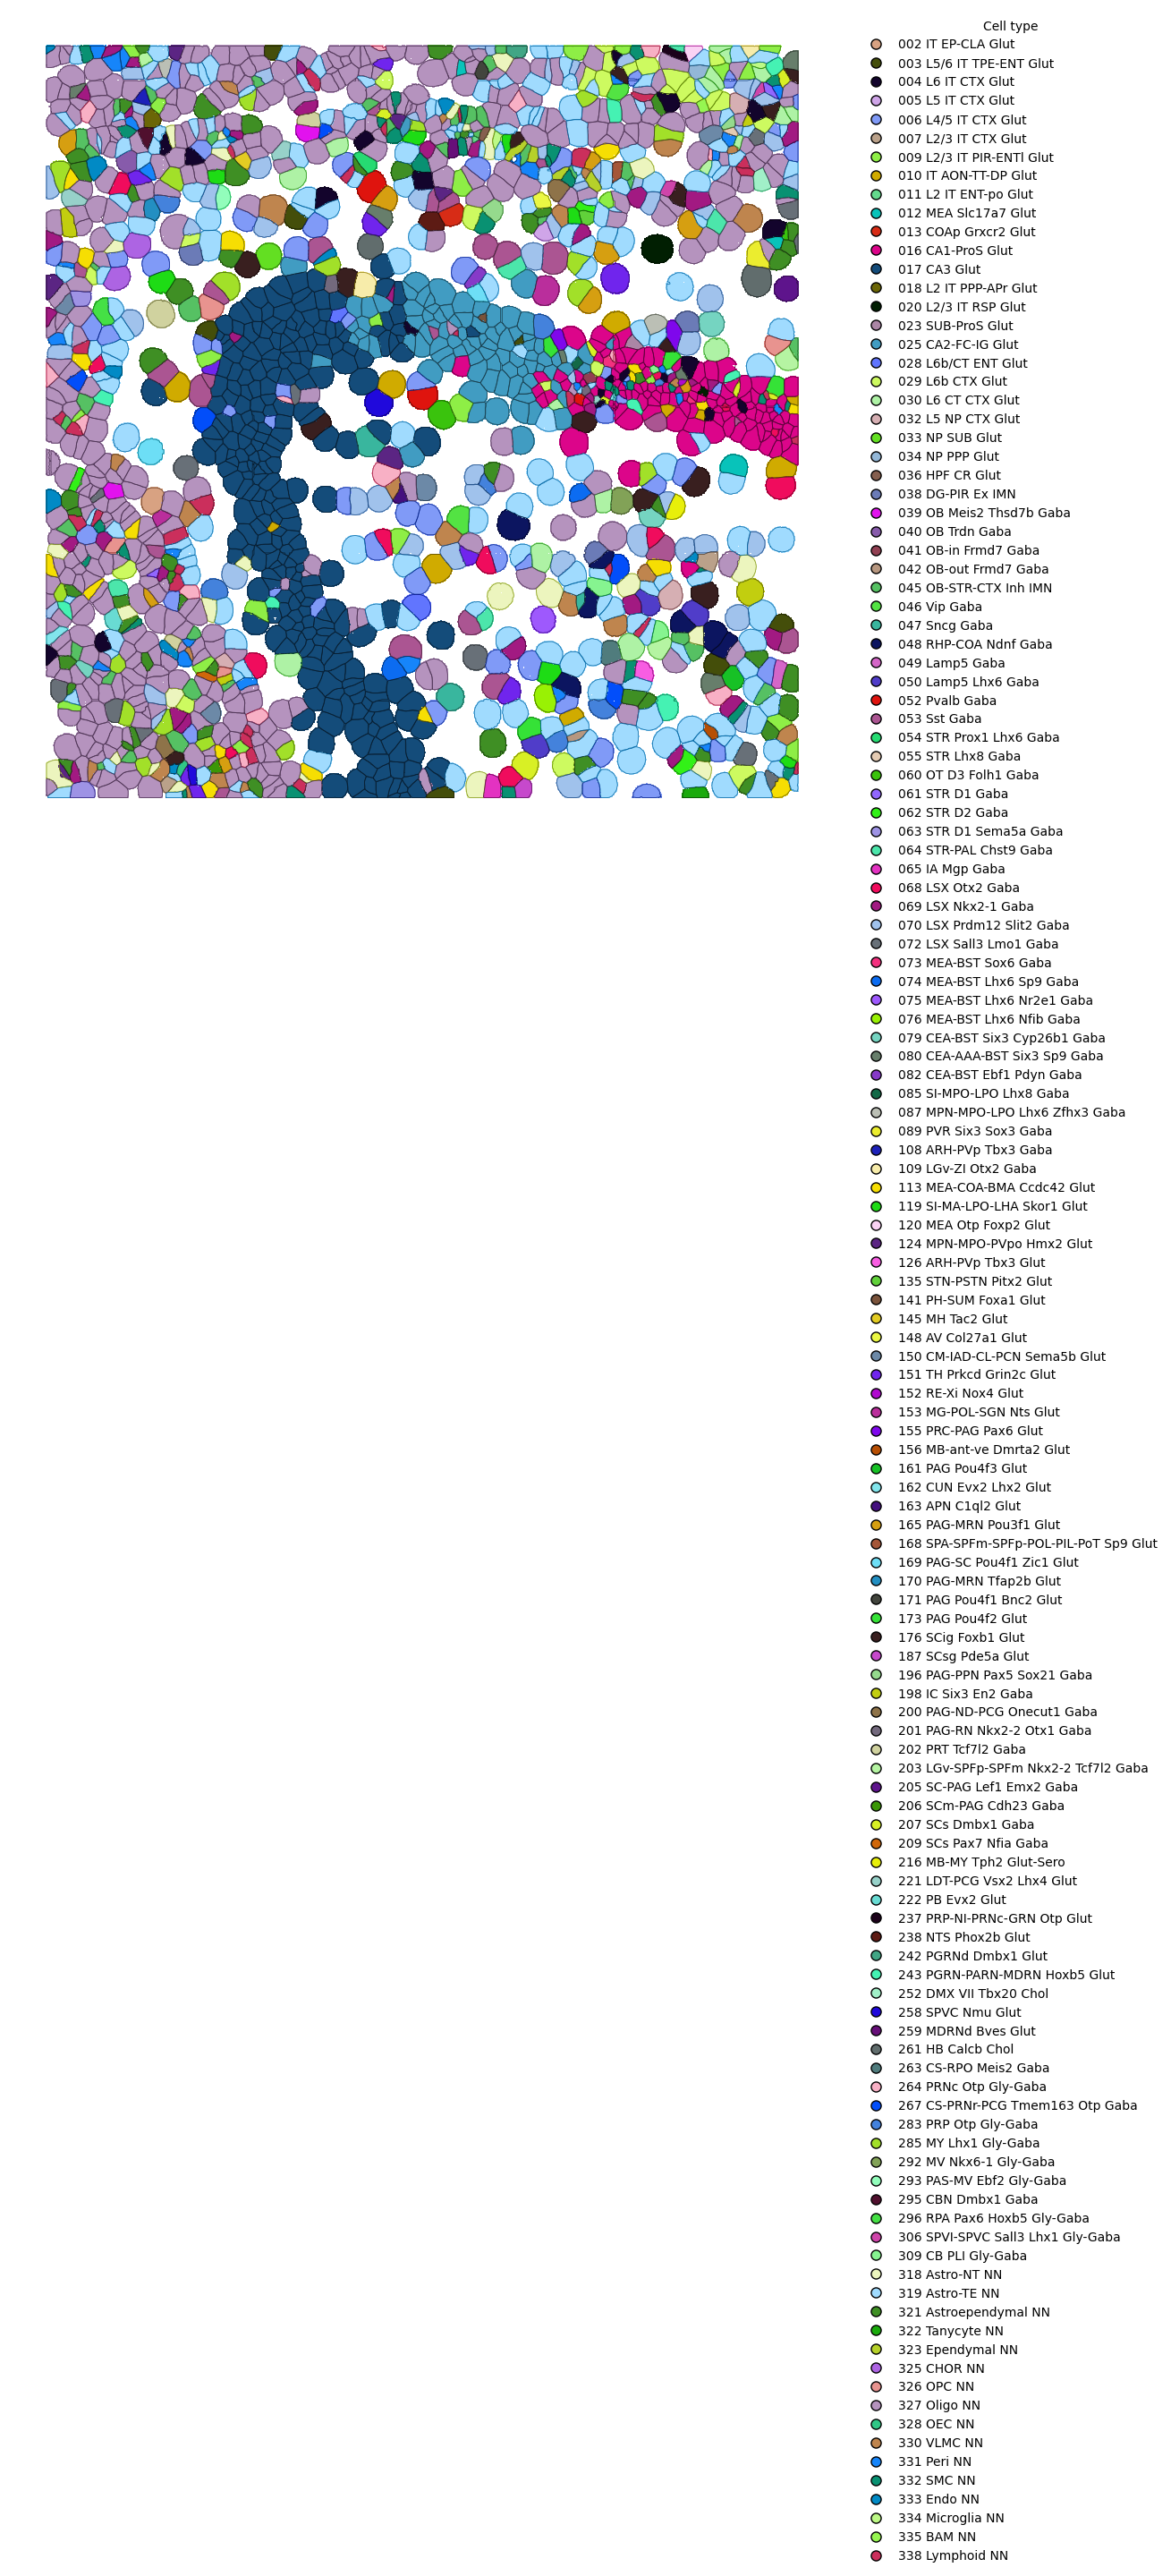

In [53]:
adata = annotated_adata

plot_bins_with_cell_boundaries(adata, cell_id_col="assigned_cell_id", label_col="celltypist_predicted_labels")